# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



# Initialization

In [2]:
for backend in ["cpu", "cuda11x", "cuda12x", "cuda", "gpu"]: 
    print(f" - Backend '{backend}': {"available" if few.has_backend(backend) else "unavailable"}")  

 - Backend 'cpu': available
 - Backend 'cuda11x': unavailable
 - Backend 'cuda12x': available
 - Backend 'cuda': available
 - Backend 'gpu': available


In [3]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [4]:
#Generating data (true)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0 #NOTE: fixed
dist = 3 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #NOTE: fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # NOTE: fixed
Phi_r0 = 0.5

In [5]:
param_true = np.array([m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0])

In [6]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [7]:
%%time
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

CPU times: user 12.7 s, sys: 475 ms, total: 13.1 s
Wall time: 13.2 s


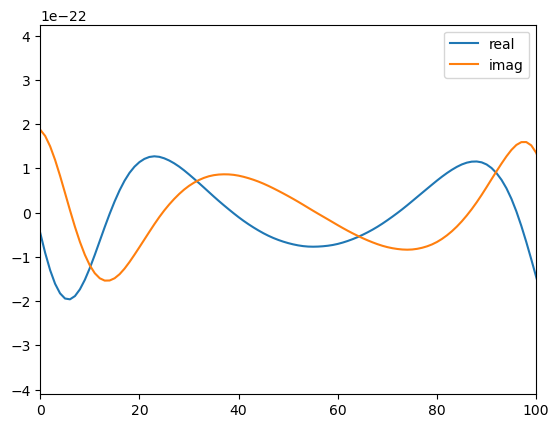

In [8]:
plt.plot(data.get().real, label='real')
plt.plot(data.get().imag, label='imag')
plt.xlim(0,100)
plt.legend(loc='upper right')
plt.show()

# Likelihood, prior

In [9]:
# def loglike(params):
#     # d: data, h: template
#     m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0 = params

#     # Set fixed values
#     phiK = phiS + np.pi/3
    
#     htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
#     res = data - htemp
#     res_f = gwf.freq_wave(res)
#     inner_res = gwf.inner(res_f, res_f)
#     return -0.5 * inner_res

In [10]:
# import time

def loglike(params):
    # start_time = time.time()
    params = np.asarray(params)

    n_samples = params.shape[0]
    # print(f'Processing {n_samples} samples')
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        # sample_start = time.time()
        # try:
        m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0 = params[i]
        phiK = phiS + np.pi/3

        # htemp_start = time.time()
        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        
        # htemp_end = time.time()
        # print(f'    Waveform generation time: {htemp_end - htemp_start:.4f}s')

        # loglike_start = time.time()
        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res
            # loglike_end = time.time()
            # print(f'    Log-likelihood computation time: {loglike_end - loglike_start:.4f}s')

            # sample_end = time.time()
            # print(f'  Sample {i+1}/{n_samples}: {sample_end - sample_start:.4f}s')

        # except Exception as e:
        #     # sample_end = time.time()
        #     # print(f'  Sample {i+1}/{n_samples}: ERROR in {sample_end - sample_start:.4f}s - {e}')
        #     log_likes[i] = -np.inf

    # end_time = time.time()
    # print(f'Total batch time: {end_time - start_time:.4f}s')
    return log_likes


In [11]:
def prior_transform(u):
    m1lim = [9.9999999974e+05, 1.0000000003e+06]
    m2lim = [2.9999843364e+01, 3.0000156636e+01]
    alim = [6.9979859020e-01, 7.0020140980e-01]
    p0lim = [7.4988920111e+00, 7.5011079889e+00]
    e0lim = [3.9994752843e-01, 4.0005247157e-01]
    distlim = [2.8977461563e+00, 3.1022538437e+00]
    qSlim = [4.3330287321e-01, 5.6669712679e-01]
    phiSlim = [9.4376145549e-01, 1.0562385445e+00]
    Phiphilim = [3.5581490499e-01, 4.4418509501e-01]
    Phirlim = [4.7878057162e-01, 5.2121942838e-01]

    transformed = np.zeros_like(u)

    # Log-uniform for masses

    # m1
    transformed[:, 0] = 10**(np.log10(m1lim[0]) + u[:, 0] * (np.log10(m1lim[1]) - np.log10(m1lim[0])))

    # m2
    transformed[:, 1] = 10**(np.log10(m2lim[0]) + u[:, 1] * (np.log10(m2lim[1]) - np.log10(m2lim[0])))
    
    # Uniform for other parameters

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # qS
    transformed[:, 6] = (qSlim[1] - qSlim[0]) * u[:, 6] + qSlim[0]

    # phiS
    transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 8] = (Phiphilim[1] - Phiphilim[0]) * u[:, 8] + Phiphilim[0]

    # Phi_r0
    transformed[:, 9] = (Phirlim[1] - Phirlim[0]) * u[:, 9] + Phirlim[0]

    
    return transformed

In [12]:
loglike([[m1+1e-5, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0]])

# Sampling

In [ ]:
config = parismc.SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=1000,                    # Use recent samples for weighting
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=100,                    # Covariance update frequency
    exclude_scale_z=np.inf,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    n_pool=4                      # Number of processes (if use_pool=True)
)

In [ ]:
import pickle
with open('cov_matrix.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

In [ ]:
ndim = 10
n_seed = 10  # Number of initial walkers/chains

In [ ]:
init_cov_list = [cov_matrix for _ in range(n_seed)]

In [ ]:
# def loglike(params):
#     params = np.asarray(params)

#     # Single sample case
#     if params.ndim == 1:
#         m1, m2, a, p0, e0, dist, qS, phiS, Phi_phi0, Phi_r0 = params
#         phiK = phiS + np.pi/3

#         htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
#                             Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
#         res = data - htemp
#         res_f = gwf.freq_wave(res)
#         inner_res = gwf.inner(res_f, res_f)
#         return -0.5 * inner_res

#     # Batch case for paris sampler
#     else:
#         n_samples = params.shape[0]
#         log_likes = np.zeros(n_samples)

#         for i in range(n_samples):
#             try:
#                 log_likes[i] = loglike(params[i])  
#             except Exception as e:
#                 log_likes[i] = -np.inf 

#     return log_likes



In [ ]:
sampler = parismc.Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=loglike,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)

In [ ]:
sampler.prepare_lhs_samples(lhs_num=int(1e5), batch_size=10)


In [ ]:
sampler.run_sampling(
    num_iterations=100, 
    savepath='./parismc_results/',
    print_iter=10 # Print progress every n iterations
)


In [ ]:
def parameter_space_search_example(n_samples=10):
    print(f"Running parameter space search with {n_samples} samples...")

    m1_range = (1.44e6, 1.56e6)
    m2_range = (14.8, 15.1)
    a_range = (0.44, 0.56)
    p0_range = (12.65, 13.35)
    e0_range = (0.1992, 0.2008) #1sigma
    dist_range = (0.98, 1.02)
    qS_range = (np.pi / 3 * 0.999, np.pi / 3 * 1.001)
    phiS_range = (np.pi / 4 * 0.999, np.pi / 4 * 1.001)
    Phi_phi0_range = (0, 2*np.pi)
    Phi_r0_range = (0, 2*np.pi)

    # Seed for reproducibility
    # np.random.seed(7)

    for i in range(n_samples):
        # Sample masses log-uniformly, others uniformly
        m1 = 10**(np.random.uniform(np.log10(m1_range[0]), np.log10(m1_range[1])))
        m2 = 10**(np.random.uniform(np.log10(m2_range[0]), np.log10(m2_range[1])))
        params = [
            float(m1),
            float(m2),
            float(np.random.uniform(*a_range)),
            float(np.random.uniform(*p0_range)),
            float(np.random.uniform(*e0_range)),
            float(np.random.uniform(*dist_range)),
            float(np.random.uniform(*qS_range)),
            float(np.random.uniform(*phiS_range)),
            float(np.random.uniform(*Phi_phi0_range)),
            float(np.random.uniform(*Phi_r0_range))
        ]

        try:
            # Evaluate likelihood
            print(f" === Parameters for sample {i+1}: {params} ===")
            logl_res = loglike(params)
            print(f"Sample {i+1}/{n_samples}: logl_res = {logl_res}")

        except Exception as e:
            print(f"Error in evaluation {i+1}: {e}")
            continue

In [ ]:
def parameter_space_search_batch_example(n_samples=10):
    total_start = time.time()
    print(f"Running batch parameter space search with {n_samples} samples...")

    m1lim = [9.9999999974e+05, 1.0000000003e+06]
    m2lim = [2.9999843364e+01, 3.0000156636e+01]
    alim = [6.9979859020e-01, 7.0020140980e-01]
    p0lim = [7.4988920111e+00, 7.5011079889e+00]
    e0lim = [3.9994752843e-01, 4.0005247157e-01]
    distlim = [2.8977461563e+00, 3.1022538437e+00]
    qSlim = [4.3330287321e-01, 5.6669712679e-01]
    phiSlim = [9.4376145549e-01, 1.0562385445e+00]
    Phiphilim = [3.5581490499e-01, 4.4418509501e-01]
    Phirlim = [4.7878057162e-01, 5.2121942838e-01]

    # Generate all samples at once
    param_gen_start = time.time()

    # Sample masses log-uniformly, others uniformly
    m1_samples = 10**(np.random.uniform(np.log10(m1lim[0]), np.log10(m1lim[1]), n_samples))
    m2_samples = 10**(np.random.uniform(np.log10(m2lim[0]), np.log10(m2lim[1]), n_samples))

    # Create batch parameter array (n_samples, n_params)
    batch_params = np.column_stack([
        m1_samples,
        m2_samples,
        np.random.uniform(*alim, n_samples),
        np.random.uniform(*p0lim, n_samples),
        np.random.uniform(*e0lim, n_samples),
        np.random.uniform(*distlim, n_samples),
        np.random.uniform(*qSlim, n_samples),
        np.random.uniform(*phiSlim, n_samples),
        np.random.uniform(*Phiphilim, n_samples),
        np.random.uniform(*Phirlim, n_samples)
    ])

    param_gen_end = time.time()
    print(f"Parameter generation time: {param_gen_end - param_gen_start:.4f}s")

    try:
        print(f"Batch parameters shape: {batch_params.shape}")
        print("Evaluating batch likelihood...")

        # Single batch evaluation with timing
        loglike_start = time.time()
        batch_results = loglike(batch_params)
        loglike_end = time.time()

        print(f"Loglike evaluation time: {loglike_end - loglike_start:.4f}s")
        print(f"Batch results shape: {batch_results.shape}")

        # Print individual results
        results_start = time.time()
        for i in range(n_samples):
            print(f"Sample {i+1}/{n_samples}: params={batch_params[i]}, loglike={batch_results[i]:.6f}")
        results_end = time.time()
        print(f"Results printing time: {results_end - results_start:.4f}s")

    except Exception as e:
        print(f"Error in batch evaluation: {e}")

    total_end = time.time()
    print(f"Total execution time: {total_end - total_start:.4f}s")
    print("Batch parameter space search completed!")

In [ ]:
%%timeit
parameter_space_search_batch_example(n_samples=10)

In [ ]:
%%timeit
parameter_space_search_example(n_samples=1)

# Analyzing Results

In [13]:
sampler = parismc.Sampler.load_state('./likelihoodtest3_results/sampler_state.pkl')

In [14]:
def visualize_marginal_distributions(sampler, savepath, true_values=None):
    """
    Create marginal distribution plots for each dimension 
    """
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
    except ImportError:
        print("Matplotlib/seaborn not available. Skipping visualization.")
        return

    print("\nCreating marginal distribution plots...")

    # Get samples and weights
    samples, weights = sampler.get_samples_with_weights(flatten=True)
    ndim = samples.shape[1]

    # Visualization parameters
    bin_num = 50
    decay = 3  # For exponential smoothing

    def exponential_smoothing(hist, decay=1.0):
        """Apply exponential smoothing to histogram."""
        smoothed = np.zeros_like(hist)
        for i in range(len(hist)):
            weights_exp = np.exp(-decay * np.abs(np.arange(len(hist)) - i))
            weights_exp /= np.sum(weights_exp)  # normalize
            smoothed[i] = np.sum(hist * weights_exp)
        return smoothed

    # Set up the plot
    sns.set(style="white", context="talk")

    # Create subplot grid
    n_rows = (ndim + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(24, 3*n_rows))

    # Flatten axes for easier indexing
    if ndim == 1:
        axes = [axes]
    elif ndim <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    for i in range(ndim):
        ax = axes[i]

        # PARIS samples
        param_samples = samples[:, i]
        hist, bin_edges = np.histogram(param_samples, bins=bin_num, weights=weights, density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        hist = exponential_smoothing(hist, decay=decay)
        ax.plot(bin_centers, hist, color='green', linewidth=2, label='PARIS')

        # Add true value red line if provided
        if true_values is not None and i < len(true_values):
            ax.axvline(true_values[i], color='red', linestyle='--', linewidth=2,
                    label='True Value' if i == 0 else "")

        # Formatting
        ax.set_title(f'Dimension {i+1} Marginal Distribution', fontsize=14)
        ax.set_ylabel('Density', fontsize=12)
        # ax.set_xlim(0, 1)
        # ax.set_xticks([0, 0.5, 1])
        # ax.tick_params(axis='x', labelsize=10)
        ax.grid(True, alpha=0.3)

        # Add legend to first subplot
        if i == 0:
            ax.legend(fontsize=10, frameon=True)

    # Remove empty subplots if ndim is odd
    if ndim % 2 == 1 and ndim > 1:
        fig.delaxes(axes[-1])

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plot_filename = os.path.join(savepath, 'marginal_distributions.png')
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Marginal distribution plot saved to: {plot_filename}")

    # Show plot if in interactive environment
    try:
        plt.show()
    except:
        pass

    # Create a 2D corner plot for the first few dimensions
    if ndim >= 2:
        create_corner_plot(samples, weights, savepath, max_dims=ndim)

def create_corner_plot(samples, weights, savepath, max_dims=4):
      """
      Create a corner plot showing 2D marginals.
      
      Parameters:
      ----------
      samples : array-like
          Sample points
      weights : array-like
          Sample weights
      savepath : str
          Save path
      max_dims : int
          Maximum number of dimensions to include
      """
      try:
          import matplotlib.pyplot as plt
          import seaborn as sns
      except ImportError:
          return

      print(f"Creating corner plot for first {max_dims} dimensions...")

      # Use only first max_dims dimensions
      samples_subset = samples[:, :max_dims]

      fig, axes = plt.subplots(max_dims, max_dims, figsize=(24, 24))

      for i in range(max_dims):
          for j in range(max_dims):
              ax = axes[i, j]

              if i == j:
                  # Diagonal: 1D marginal
                  hist, bin_edges = np.histogram(samples_subset[:, i], bins=30, weights=weights, density=True)
                  bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
                  ax.plot(bin_centers, hist, color='green', linewidth=2)
                #   ax.set_xlim(0, 1)
                  ax.set_title(f'Dim {i+1}')

              elif i > j:
                  # Lower triangle: 2D scatter
                  scatter = ax.scatter(samples_subset[:, j], samples_subset[:, i],
                                     c=weights, s=1, alpha=0.6, cmap='viridis')
                #   ax.set_xlim(0, 1)
                #   ax.set_ylim(0, 1)

              else:
                  # Upper triangle: empty
                  ax.axis('off')

              if i == max_dims - 1:
                  ax.set_xlabel(f'Dimension {j+1}')
              if j == 0 and i > 0:
                  ax.set_ylabel(f'Dimension {i+1}')

      plt.tight_layout()
      corner_filename = os.path.join(savepath, 'corner_plot.png')
      plt.savefig(corner_filename, dpi=300, bbox_inches='tight')
      print(f"Corner plot saved to: {corner_filename}")

      try:
          plt.show()
      except:
          pass

In [15]:
# Create visualizations
visualize_marginal_distributions(sampler, './likelihoodtest3_results/', true_values=param_true)
# TODO: change the visualization function to delete MODES or smth


In [16]:
# try corner
import corner
samples, weights = sampler.get_samples_with_weights(flatten=True)
labels = [r'$m_1$', r'$m_2$',r'$a$',r'$p_0$',r'$e_0$',r'dist',r'$q_S$', r'$\phi_S$',
        r'$\Phi_{\phi,0}$', r'$\Phi_{r,0}$']

fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50
)

In [17]:
len(sampler.searched_log_densities_list[0])

In [18]:
sampler.searched_log_densities_list[0].max()

In [19]:
sampler.searched_log_densities_list[0][0]

In [20]:
sampler.searched_log_densities_list[0]